In [40]:
from importlib import reload
import torch
import numpy as np
import time
import os
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
print(device)
cupy_device = device.index if device.type == "cuda" else 0
import numpy as np
import sys # Add the module path. Windows and Linux use different path separators; the raw string prevents escape sequences such as \n from being interpreted.
sys.path.append(r"../main_code/2d")
import generate_data,mesh,adaptive_int,visual,matrix_assemble,inverse_solver,mea_2d,net_2d,source_eval,error_general_2d,main
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"


def f_circle(x,x_left,x_right,y_below,y_upper,center,r):
    # Compute r_y = sqrt((x1 - y1)^2 + (x2 - y2)^2 + (x3 - y3)^2)
    r_y = np.linalg.norm(x - center, axis=-1)
    # Apply the piecewise function
    f_y_values = np.where(r_y < r , 1.0, 0.0)
    return f_y_values

def f_rec(x,x_left,x_right,y_below,y_upper,center,r):
    cond= (x[:,0]>=x_left) & (x[:,0]<=x_right) & (x[:,1]>=y_below) & (x[:,1]<=y_upper)
    return cond*1

def ana_S(x,x_left,x_right,y_below,y_upper,center,r): # x is the data array; a and b are center coordinates
    return f_circle(x,x_left,x_right,y_below,y_upper,center,r)-f_rec(x,x_left,x_right,y_below,y_upper,center,r)


cuda:2


### noise=5%

In [41]:
import copy
Nx,Ny=1,1
Ix,Iy=4,4  # Number of grid cells in the x direction
nx,ny=3,3  # Gauss points per cell in the x direction
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81,85,89]
tau_x_min,tau_x_max,tau_y_min,tau_y_max=0,1,0,1
b_x_min,b_x_max,b_y_min,b_y_max=-0.5,1.5,-0.5,1.5 # On boundary Gamma

num_batches_gauss=1
b_n=10
points_b=mea_2d.p_b(b_x_min,b_x_max,b_y_min,b_y_max,b_n) # Collect data on boundary Gamma
x_left,x_right,y_below,y_upper=0.29,0.49,0.3,0.7
r_true=0.2
center_true=np.array([0.71,0.5])
number_gene=50
eps=0.05
batch_number_rec_mea,mea=2,1
cupy_device = device.index if device.type == "cuda" else 0
S_int_true1, F_mea_b1, F_mea_db_x11, F_mea_db_x21 = generate_data.boundary_data_rec(kk, number_gene,points_b, f_rec, x_left,x_right,y_below,y_upper, center_true, r_true, eps,mea,batch_number_rec_mea,device,cupy_device)
S_int_true2, F_mea_b2, F_mea_db_x12, F_mea_db_x22 = generate_data.boundary_data_circle(kk, number_gene,points_b, f_circle, x_left,x_right,y_below,y_upper, center_true, r_true, eps,mea,batch_number_rec_mea,device,cupy_device)
F_mea_b_5 = -F_mea_b1 + F_mea_b2
F_mea_db_x1_5 = -F_mea_db_x11 + F_mea_db_x12
F_mea_db_x2_5 = -F_mea_db_x21 + F_mea_db_x22
F_5=inverse_solver.F(F_mea_b_5,F_mea_db_x1_5,F_mea_db_x2_5)

cells= mesh.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,Ix,nx,points_b) # Create the initial grid
initial_cells=copy.deepcopy(cells) # Make a copy
R_m=20


In [42]:
M=400
af="Tanh"   # Initial activation setting
R_m=20
cupy_device = device.index if device.type == "cuda" else 0
models = net_2d.pre_define(Nx,Ny,M,R_m,af,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],device)


In [43]:
models = torch.load("./MA_RFM_5%/M=400+200*2/models0_33_400_6381_10-4.pth")

/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


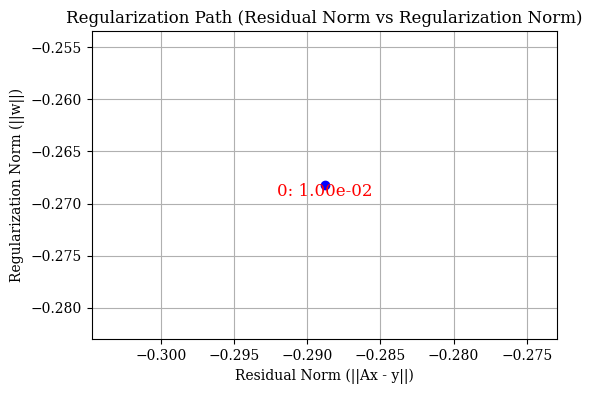

第 0 次迭代的train误差：
第 0 次迭代的泛化误差：


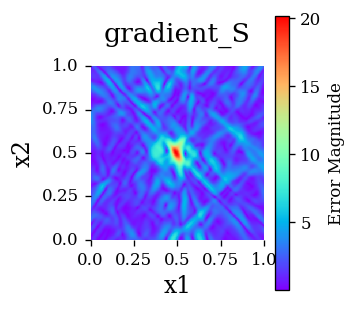

S_l_inf= 2.4736940846706736 S_L_2= 0.36725367612835724 S_l_2= 0.8131045953105968


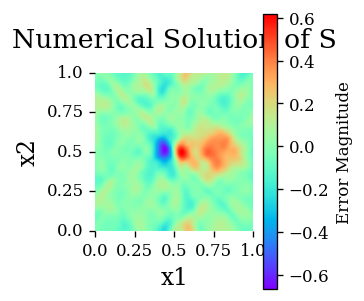

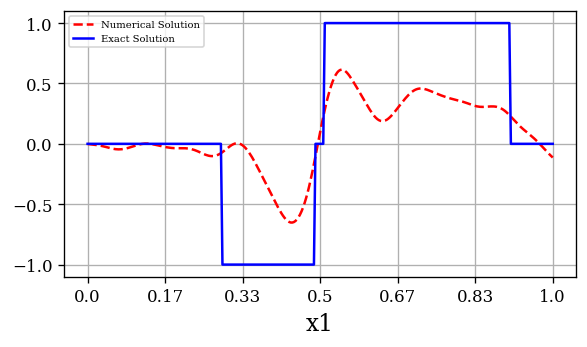

第 0 次自适应网格细分...
Generating visualizations...
1. Plotting mesh comparison...


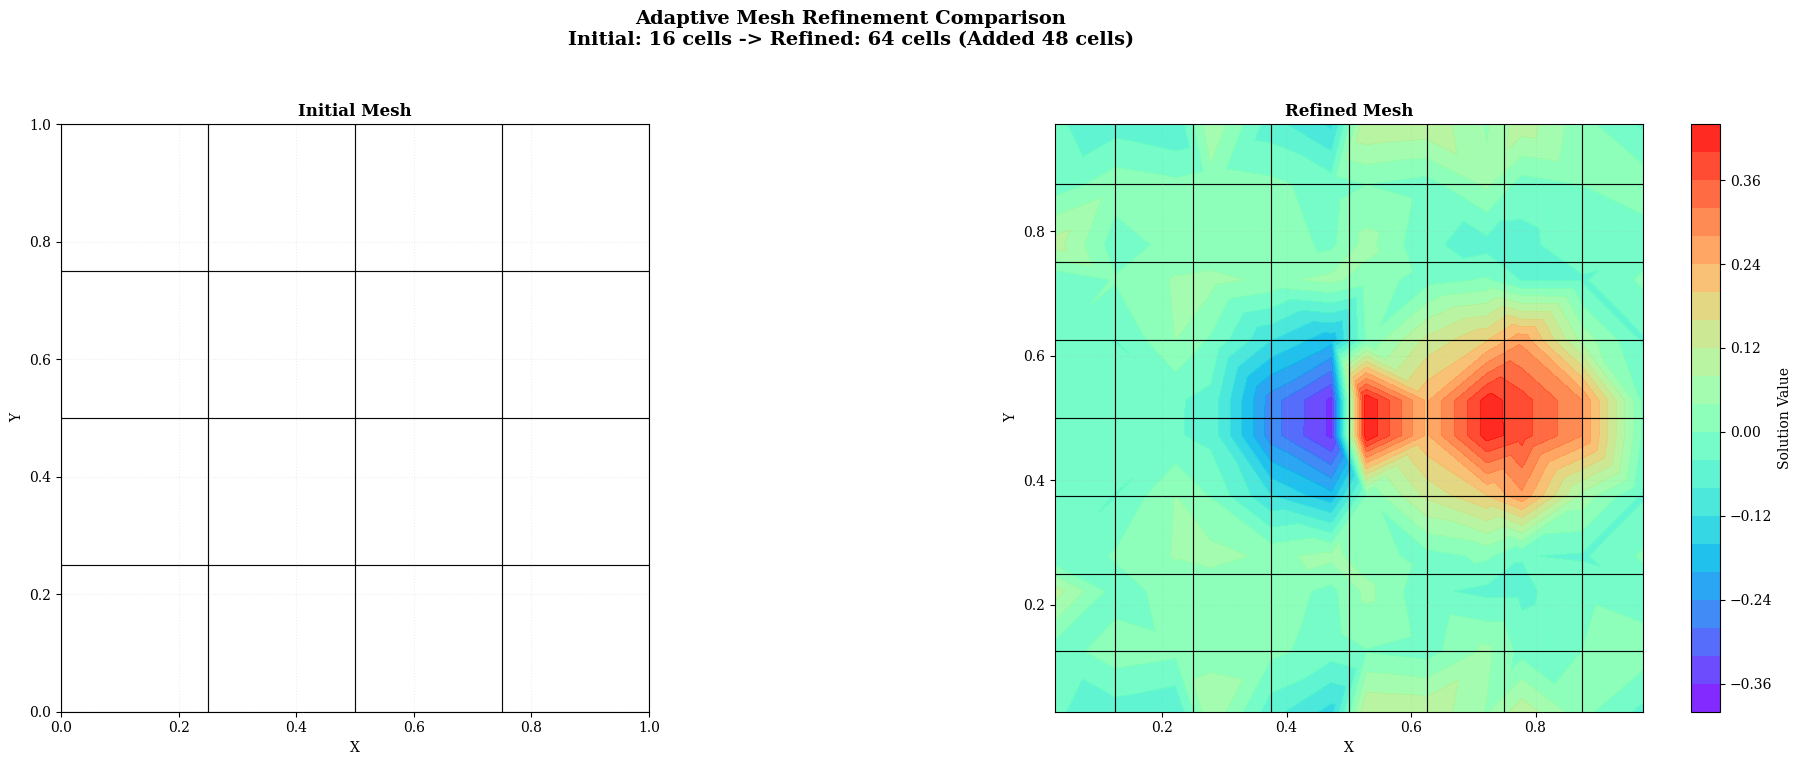

All visualizations completed!


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


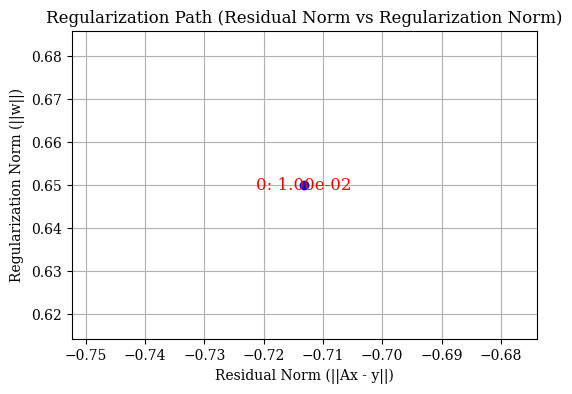

第 1 次迭代的train误差：
第 1 次迭代的泛化误差：


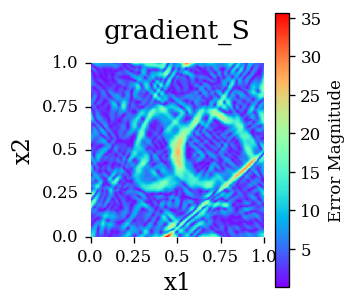

S_l_inf= 1.8277684011101565 S_L_2= 0.16156796648170094 S_l_2= 0.35771365827075985


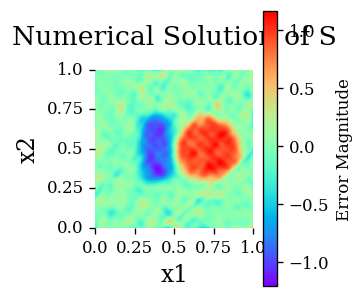

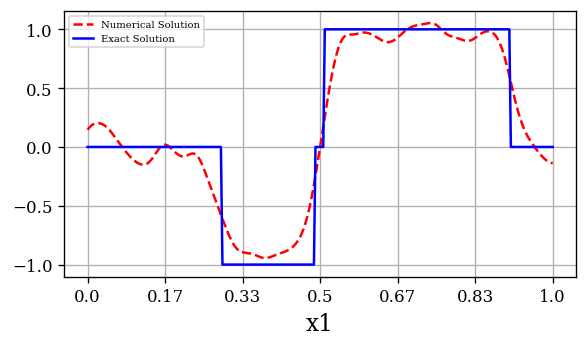

第 1 次自适应网格细分...
Generating visualizations...
1. Plotting mesh comparison...


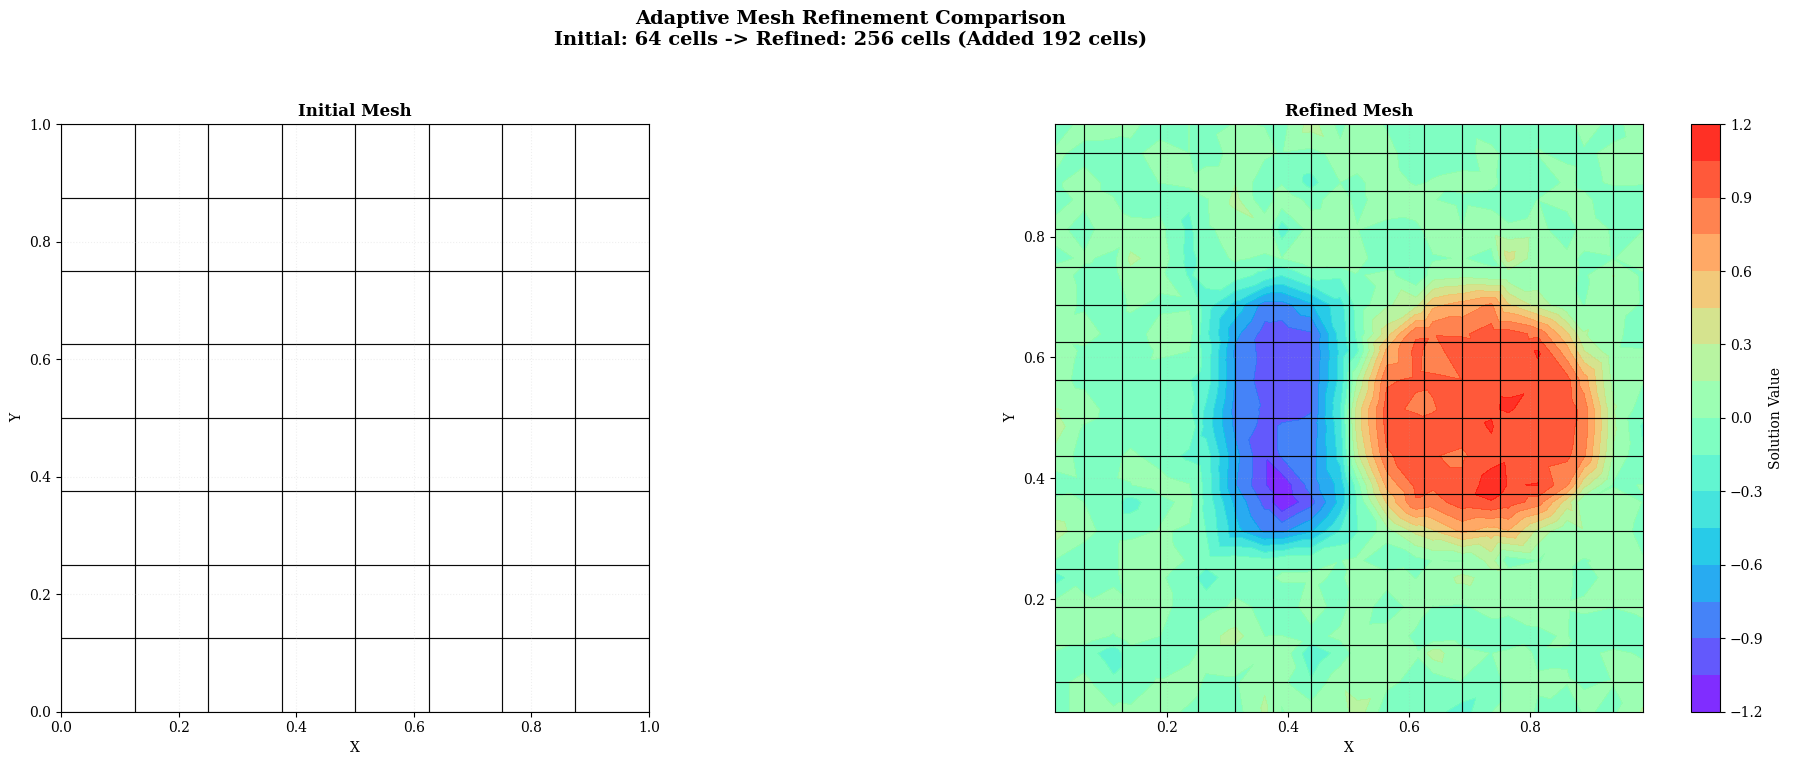

All visualizations completed!


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


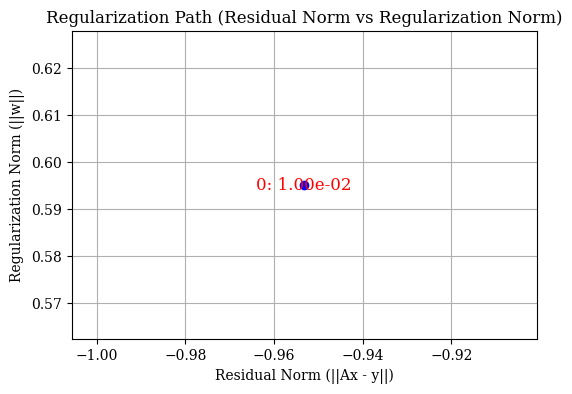

第 2 次迭代的train误差：
第 2 次迭代的泛化误差：


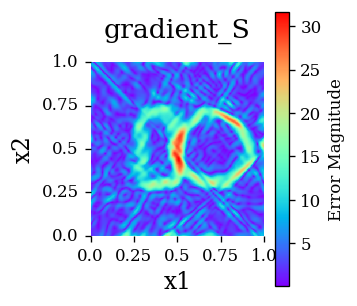

S_l_inf= 1.6849232956343347 S_L_2= 0.1337461415489066 S_l_2= 0.2961157623932643


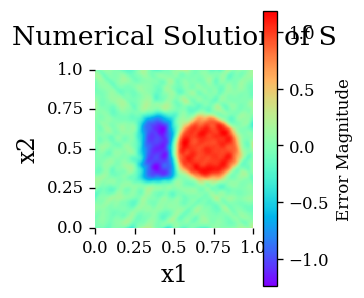

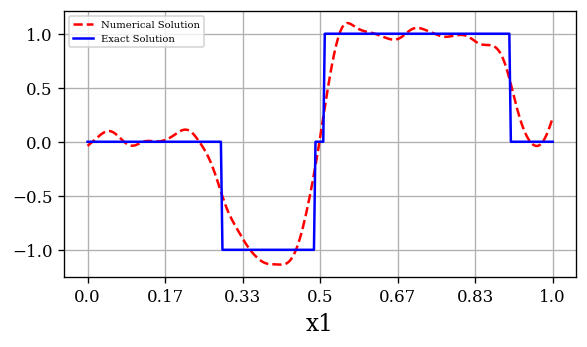

第 2 次自适应网格细分...
Generating visualizations...
1. Plotting mesh comparison...


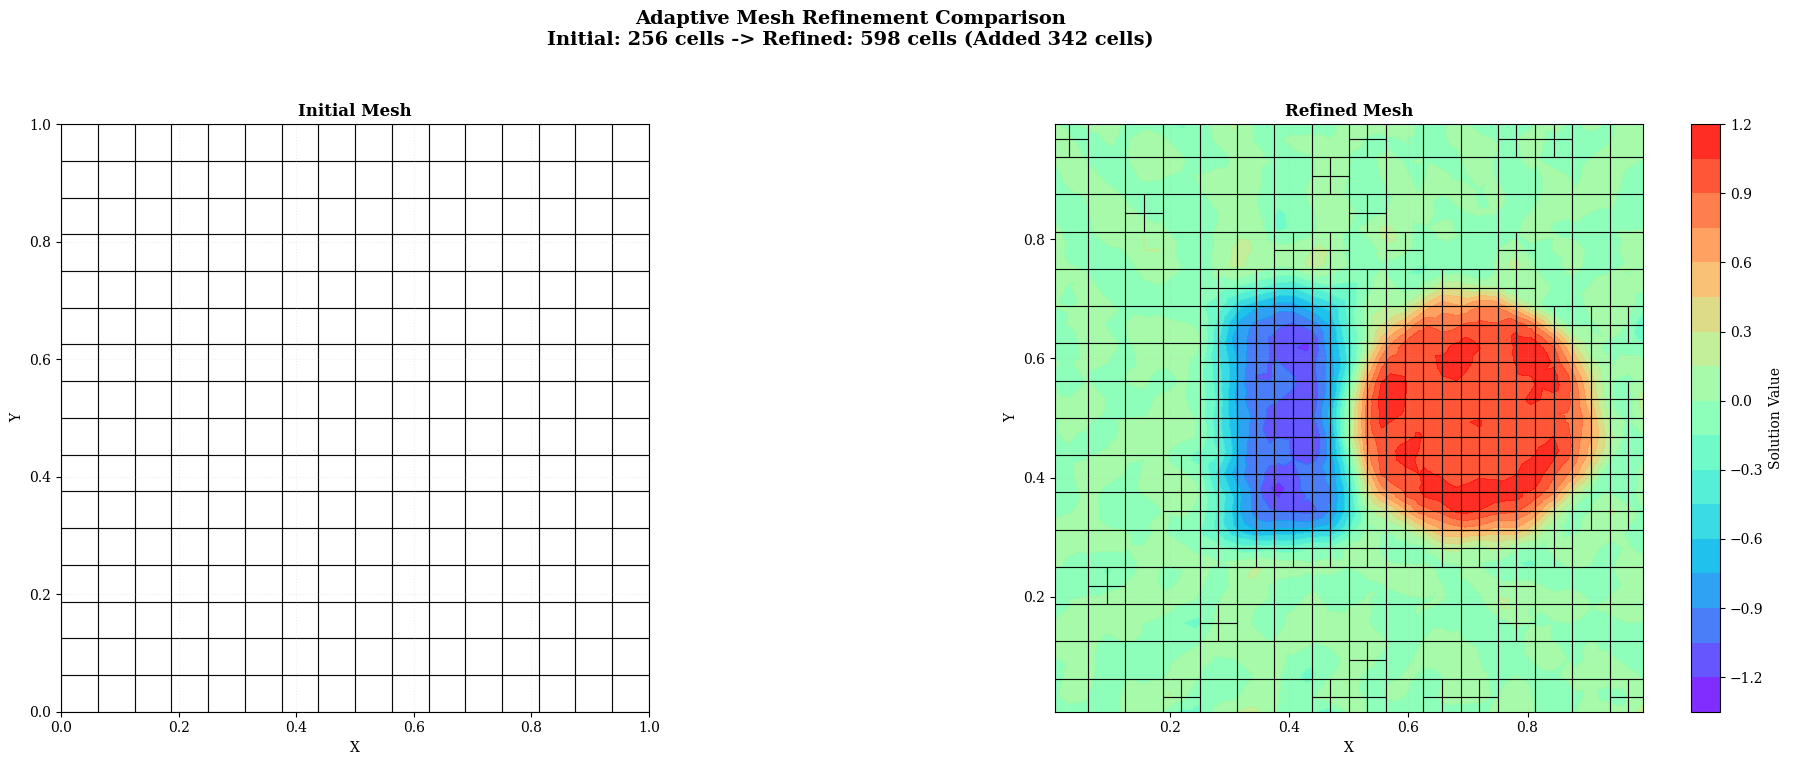

All visualizations completed!


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


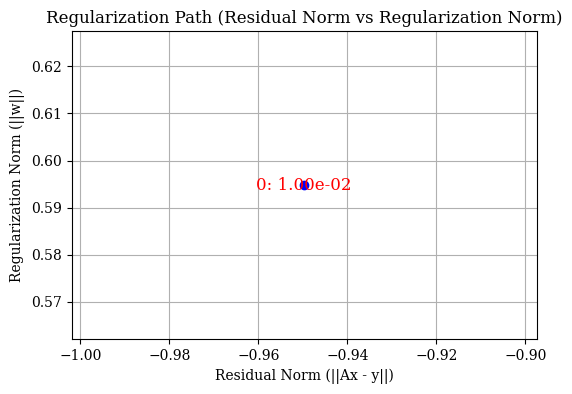

第 3 次迭代的train误差：
第 3 次迭代的泛化误差：


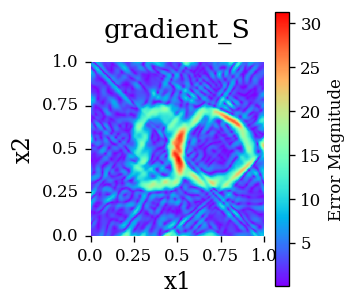

S_l_inf= 1.6690950790409878 S_L_2= 0.1336864577745532 S_l_2= 0.2959836217113688


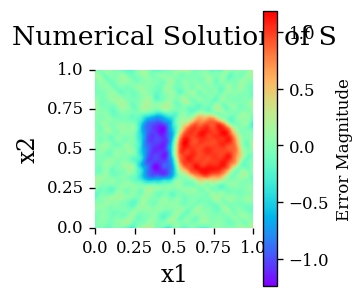

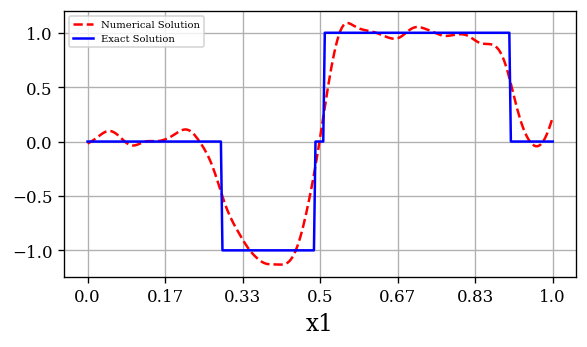

第 3 次自适应网格细分...
Generating visualizations...
1. Plotting mesh comparison...


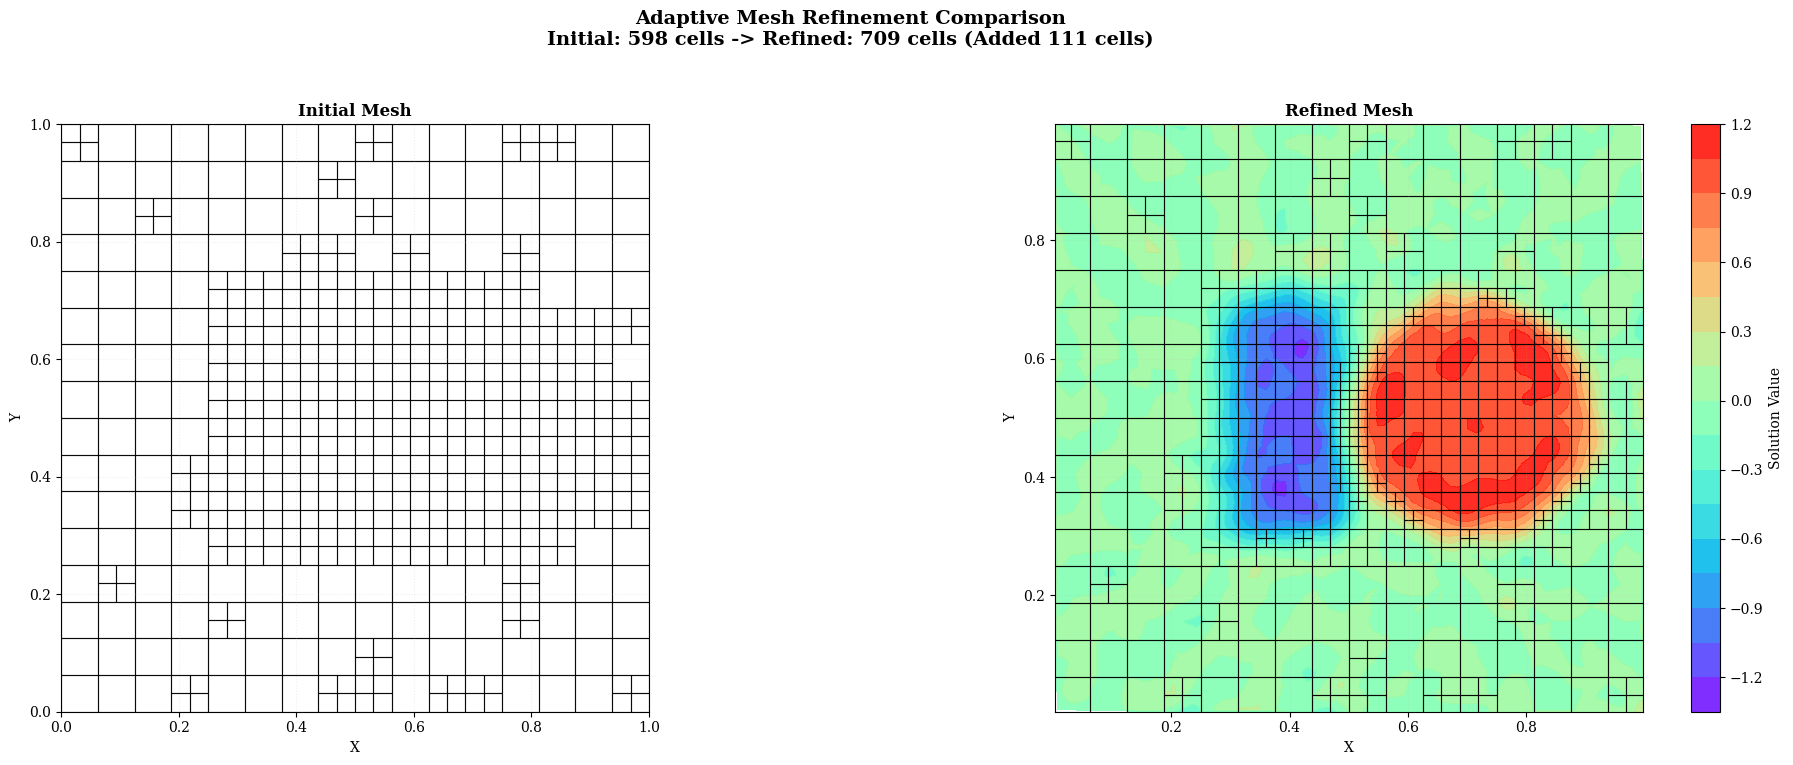

All visualizations completed!


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


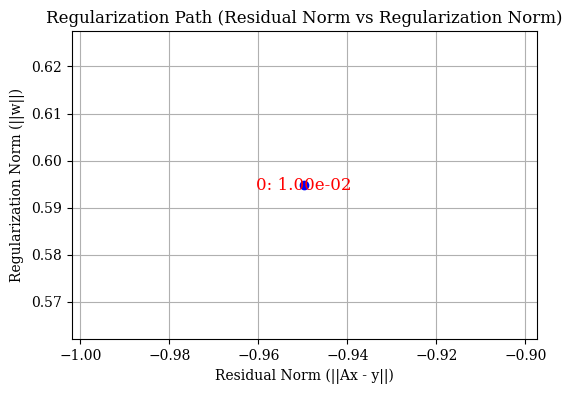

第 4 次迭代的train误差：
第 4 次迭代的泛化误差：


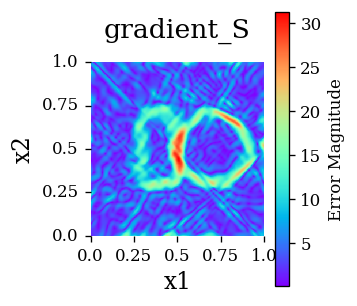

S_l_inf= 1.6690804953141094 S_L_2= 0.13368608384834893 S_l_2= 0.2959827938337062


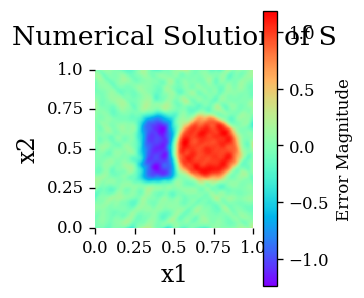

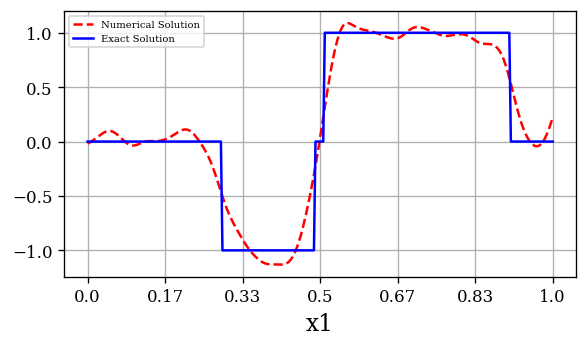

在第 4 次迭代结束


In [44]:
iter_int= 5
Ix,Iy=4,4  # Number of grid cells in the x direction
delta=10**(-3)
nx=3
lamb_regu=np.logspace(-2,-1,1)
Qx,Qy=150,150
max_level=4
current_maxiter=1
af="Tanh"
refine_threshold_S=1/100
refine_threshold_grad=1/300
Shape=[]
cells_store,refinement_stats_store,w_,point_number,S_num_store,g_store,g_S,S_l2=main.ada_int(iter_int,delta,cells,nx,models,M,af,Shape,kk,F_5,tau_x_min,tau_x_max,tau_y_min,tau_y_max,x_left,x_right,y_below,y_upper,center_true,r_true,ana_S,points_b,lamb_regu,Qx,Qy,device,cupy_device,refine_threshold_S,refine_threshold_grad,current_maxiter,max_level)


Number of detected clusters: 2
  CV of S_num: 0.242
Cluster 0: AR=1.95
  Res_Rect=0.152168 vs Res_Ellip=0.148105
  center=(0.3958, 0.5055)
  -> Decision: Ellipsoid (Sigmoid)
  CV of S_num: 0.240
Cluster 1: AR=1.01
  Res_Rect=0.107264 vs Res_Ellip=0.047672
  center=(0.7124, 0.4885)
  -> Decision: Circle (Sigmoid)


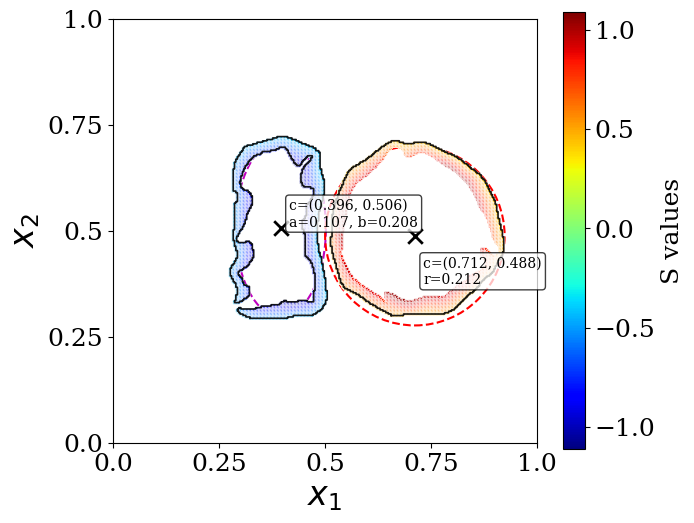

In [45]:
import bound_detect
reload(bound_detect)
x=np.linspace(tau_x_min,tau_x_max,301)
y=np.linspace(tau_y_min,tau_y_max,301)
X,Y=np.meshgrid(x,y)
eps_cluster=5.0
mini_samples=20
para_abs=3
para_grad=3
results=bound_detect.detect_shape(g_S,X.T,Y.T,tau_x_min,tau_x_max,tau_y_min,tau_y_max,para_abs,para_grad,eps_cluster,mini_samples,S_num_store[-1],output_directory="./MA_RFM_5%/M=400+200*2", output_filename="plot.png", eps_mode="grid_scaled")

In [46]:
results

[{'cluster_id': 0,
  'shape': 'Ellipsoid',
  'params': {'center': array([0.39583333, 0.50551036]),
   'a': np.float64(0.10666666666666669),
   'b': np.float64(0.20833333333333334)},
  'profile': 'Sigmoid',
  'boundary_points': array([[0.32393333, 0.2936    ],
         [0.32393333, 0.29422667],
         [0.32393333, 0.29485333],
         ...,
         [0.32581333, 0.2936    ],
         [0.32518667, 0.2936    ],
         [0.32456   , 0.2936    ]])},
 {'cluster_id': 1,
  'shape': 'Circle',
  'params': {'center': array([0.71241546, 0.48849625]),
   'radius': np.float64(0.21175434269467067)},
  'profile': 'Sigmoid',
  'boundary_points': array([[0.65672333, 0.30004   ],
         [0.65672333, 0.30065   ],
         [0.65672333, 0.30126   ],
         ...,
         [0.65855333, 0.30004   ],
         [0.65794333, 0.30004   ],
         [0.65733333, 0.30004   ]])}]

In [47]:
center1=results[0]['params']['center']
width=results[0]['params']['a']*2
height=results[0]['params']['b']*2
center2=results[1]['params']['center']
r=results[1]['params']['radius']


In [48]:
import net_2d

r_min=(1-0.1)*r
r_max=(1+0.05)*r
K_min=1000
K_max=20000
min_rec1,max_rec1,min_rec2,max_rec2=-center1[0]*(1+0.05),-center1[0]*(1-0.05),-center1[1]*(1+0.05),-center1[1]*(1-0.05)
min_c1,max_c1,min_c2,max_c2=-center2[0]*(1+0.05),-center2[0]*(1-0.05),-center2[1]*(1+0.05),-center2[1]*(1-0.05)
width_min,width_max=width*(1-0.1),width*(1+0.05)
height_min,height_max=height*(1-0.1),height*(1+0.05)
models0=models
models1= net_2d.pre_define(Nx, Ny,2400,R_m,"sigmoid",tau_x_min,tau_x_max,tau_y_min,tau_y_max,r_min,r_max,min_c1,max_c1,min_c2,max_c2,[],[],[],[],[],[],[],[],K_min,K_max,"circle",device)
models2= net_2d.pre_define(Nx, Ny,2400,R_m,"sigmoid",tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],min_rec1,max_rec1,min_rec2,max_rec2,width_min,width_max,height_min,height_max,[],[],[],[],K_min,K_max,"rec",device)
af="mix"
sum_mat,all_g_p1,all_g_n,cells_copy1=matrix_assemble.mat_assemble2(cells_store[-1],models0,models1,models2,"mix","circle","rec",kk,0,points_b,device,cupy_device)


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


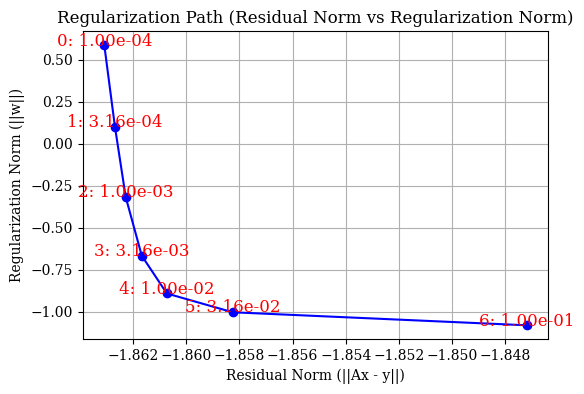

In [49]:
lamb_regu=np.logspace(-4,-1,7,endpoint=True)
res,reg_norm,w_store=inverse_solver.L_curve(sum_mat,F_5,[],[],[],lamb_regu,"linear",device,cupy_device) # Solve first for q


lamb: 0.0009999999999999998


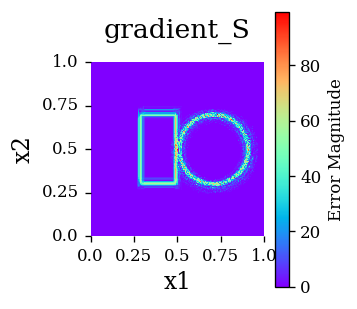

S_l_inf= 1.6555979084268544 S_L_2= 0.06706572439227422 S_l_2= 0.14848441890649203


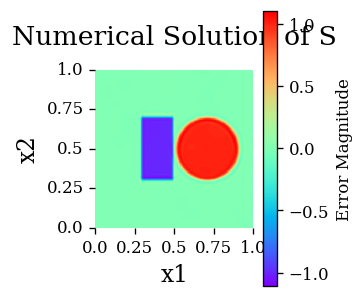

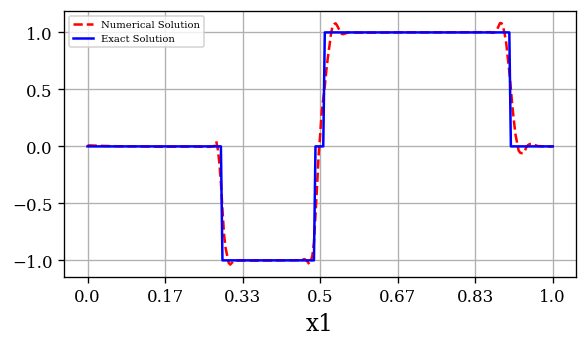

In [50]:
lamb=lamb_regu[5]**2
print('lamb:',lamb)
Qx,Qy=150,150
S_test_num,S_test_true,S_l_inf1,S_l_21,g_SS=error_general_2d.test(models0,models1,models2,[],Qx,Qy,w_store[:,5],"mix","circle","rec",True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,x_left,x_right,y_below,y_upper,center_true,r_true,ana_S,1,device)


In [51]:
np.save("./MA_RFM_5%/M=400+200*2/g_S1",g_SS)


In [52]:
import pickle

with open("./MA_RFM_5%/M=400+200*2/cells_store_last.pkl", "wb") as f:
    pickle.dump(cells_store[-1], f)

In [53]:
np.save("./MA_RFM_5%/M=400+200*2/S_num_400+200*2_10-4",S_test_num)
np.save("./MA_RFM_5%/M=400+200*2/all_mat",sum_mat)
np.save("./MA_RFM_5%/M=400+200*2/w_store",w_store)
np.save("./MA_RFM_5%/M=400+200*2/F_mea_b",F_mea_b_5)
np.save("./MA_RFM_5%/M=400+200*2/F_mea_db_x1",F_mea_db_x1_5)
np.save("./MA_RFM_5%/M=400+200*2/F_mea_db_x2",F_mea_db_x2_5)

In [54]:
# Save the models1 model
torch.save(models0,f"./MA_RFM_5%/M=400+200*2/models0_33_400_{point_number[-1]}_10-4.pth")
torch.save(models1,f"./MA_RFM_5%/M=400+200*2/models1_33_200_circle.pth")
torch.save(models2,f"./MA_RFM_5%/M=400+200*2/models2_33_200_rec.pth")

In [55]:
np.save("./MA_RFM_5%/M=400+200*2/g_S1",g_SS)

In [56]:
parameters5 = {
    "I_grid":Ix,
    "gauss_n":nx,
    "number_gene":number_gene,
    "noise":eps,
    "k": kk,
    "M0": 400,
    "M1": 200,
    "M2": 200,
    "Tanh_Rm":20,
    "Gauss_R_m": R_m,
    "refinement_stats_store":refinement_stats_store,
    "points_number_ada:":point_number,
    "r_min": r_min,
    "r_max": r_max,
    "min_rec1": min_rec1,
    "max_rec1": max_rec1,
    "min_rec2": min_rec1,
    "max_rec2": max_rec1,
    "width_min": width_min,
    "width_max": width_max,
    "height_min": height_min,
    "height_max": height_max,
    "min_circle1":min_c1,
    "max_circle1":max_c1,
    "min_circle2":min_c2,
    "max_circle2":max_c2,
    "K_min": K_min,
    "K_max": K_max,
}

In [57]:
## Print n_integral: len(cell_stores[-1])*9, center[0], width, height, center[1], r, S_l2[-1], lamb_regu**2, S_l21
# Print in list form. 
n_integral=len(cells_store[-1])*9
print('n_integral:',n_integral)
print('center1[0]:',center1)
print('center2[1]:',center2)
print('width:',width)
print('height:',height)

print('r:',r)
print('S_l2[-1]:',S_l2[-1])
print('lamb_regu:',lamb)
print('S_l21:',S_l_21)

n_integral: 6381
center1[0]: [0.39583333 0.50551036]
center2[1]: [0.71241546 0.48849625]
width: 0.21333333333333337
height: 0.4166666666666667
r: 0.21175434269467067
S_l2[-1]: 0.2959827938337062
lamb_regu: 0.0009999999999999998
S_l21: 0.14848441890649203
